In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from mad.objs.base import MovableObj
from mad.objs.planets import Planet, PlanetConfig
from mad.utils import to_voxel_key
from mad.objs.radars import Radar, RadarConfig
import matplotlib.pyplot as plt
import numpy as np

from mad.configs.planets import EARTH_SETTINGS
from mad.configs.physics import VOXEL_SIZE_KM

In [9]:
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
radar_cfg = RadarConfig(
    position = [earth.radius + 10.0, 0.0],
    range_km=5_000.0,
    altitude_km=0.0,
    name="TestRadar",
    voxel_size_km=2000
)

radar = Radar(radar_cfg, earth)

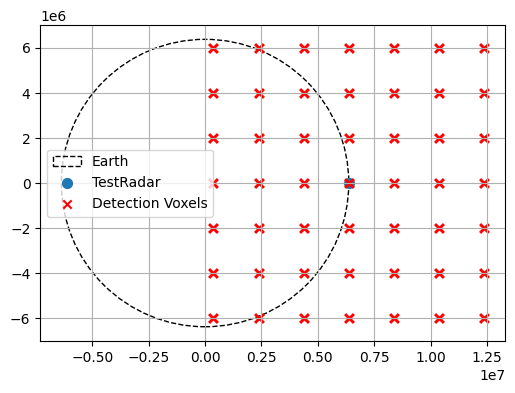

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
earth.plot_2D_with_points([radar], display_planet=True, ax=ax)

voxels = np.array(list(radar.detection_voxels)) * radar.voxel_size_km * 1000.0 + radar.position
ax.scatter(voxels[:, 0], voxels[:, 1], c='r', marker='x', label='Detection Voxels')


ax.legend()